In [1]:
import sys
import os
sys.path.append("../../src/")
#Imports
import single_particle_sector as sps
import kblock_ising_model as kb
import numpy as np
import scipy as sp
import numpy.linalg as la
import matplotlib.pyplot as plt
from matplotlib.pyplot import plot, scatter


In [2]:
def power_law(x,A,B):
    return A*x**B
def exp_law(x,A,B,C):
    return A*np.exp(-B*x)+C

In [3]:
#Params
L = 1000
J = 1
g = 1
k = kb.k_vals(L)
U = kb.U(k,g)
x= np.arange(0,50,dtype=int)

In [4]:
X = np.arange(25)

dat = [kb.sigma_general([0,xi],U,k) for xi in X]
#dat = [np.exp(-2*xi) for xi in X]

/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/scaling_dim/../../src/kblock_ising_model.py:130: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,T,k)


In [ ]:
from scipy.optimize import curve_fit
def power_law(x,A,B):
    return A*x**B
def exp_law(x,A,B,C):
    return A*np.exp(-B*x)+C
def fit(dat,X):
    params_power_law , cov_power_law = curve_fit(power_law, X, dat)
    #a_power_law, b_power_law = params_power_law
    params_exp_law, cov_exp_law = curve_fit(exp_law,X,dat,maxfev=1000)
    plt.scatter(X,dat)
    plt.loglog(X,power_law(X,*params_power_law),label=f"powerlaw, b = {str(params_power_law[1])[:6]}")
    plt.loglog(X,exp_law(X,*params_exp_law),label=f"exp law, b = {str(params_exp_law[1])[:5]}")
    plt.legend()
    plt.xlim(X[0],X[-1])
    #plt.ylim(0,1)
    plt.show()
    print(np.sqrt(np.diag(cov_power_law)))
    print(np.sqrt(np.diag(cov_exp_law)))
    return params_power_law, params_exp_law



/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/scaling_dim/../../src/kblock_ising_model.py:130: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,T,k)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_8714/324060891.py:4: RuntimeWarning: overflow encountered in exp
  return A*np.exp(-B*x)+C
/var/folders/tb/9nr_h

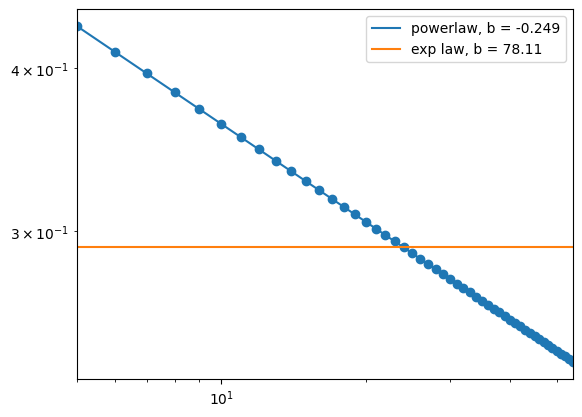

[4.95728766e-05 2.49629283e-05]
[inf inf inf]


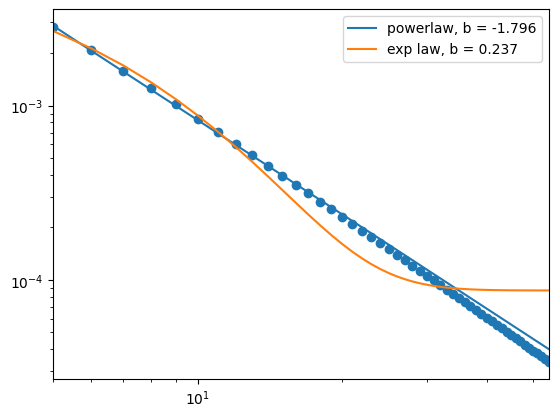

[0.00062848 0.00629044]
[3.87167919e-04 6.96315035e-03 9.50669052e-06]


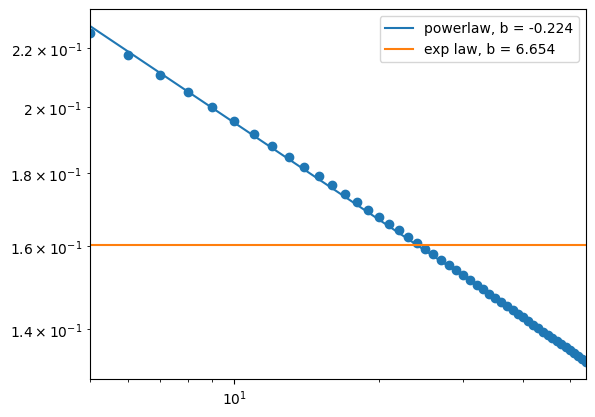

[0.0008878  0.00087335]
[inf inf inf]


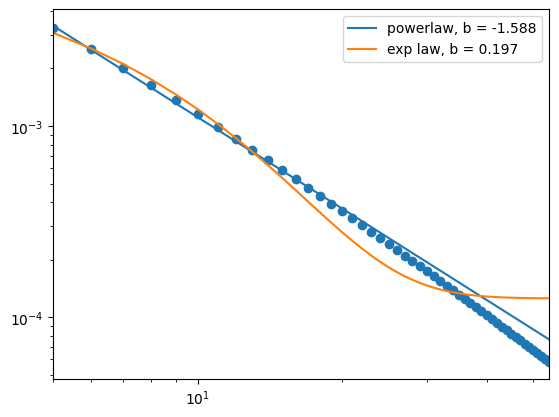

[0.00091546 0.01057691]
[3.05366975e-04 5.62343473e-03 1.15751108e-05]


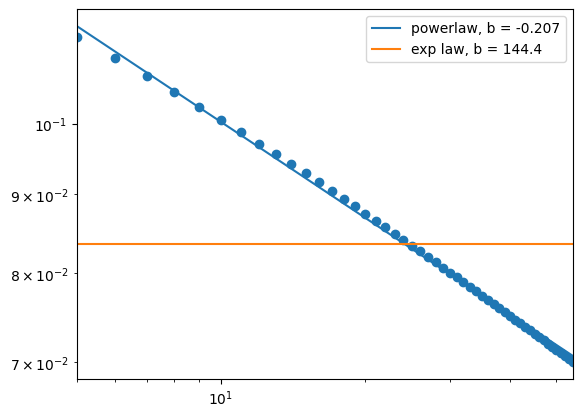

[0.00066074 0.00131111]
[inf inf inf]


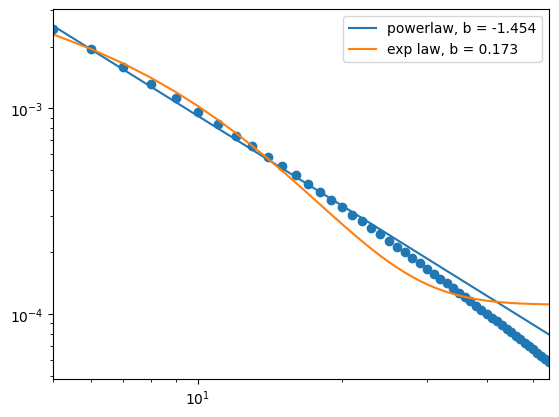

[0.00068121 0.01256119]
[1.78305546e-04 4.83627405e-03 9.03928996e-06]


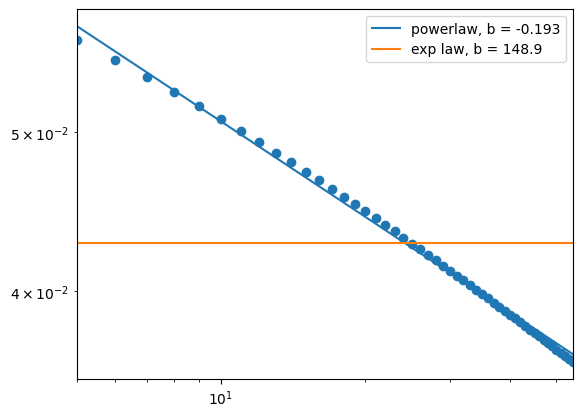

[0.00038425 0.00154702]
[inf inf inf]


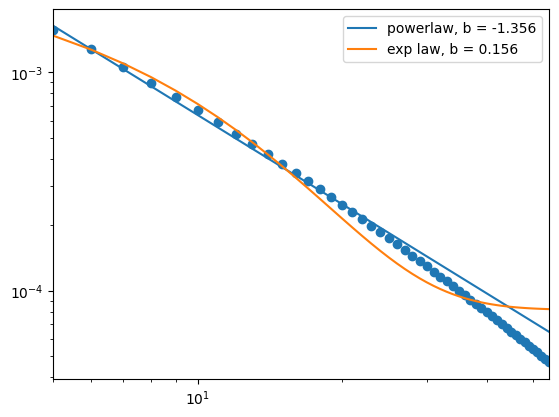

[0.00041582 0.0135478 ]
[9.55320564e-05 4.31579340e-03 6.00946264e-06]


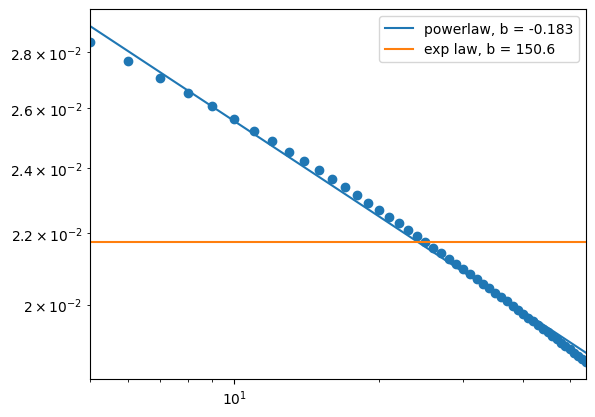

[0.00020506 0.00167639]
[inf inf inf]


In [272]:
X = np.arange(5,55)

N = 0
dat = [kb.sigma_general([0,xi],U,k)-N**2 for xi in X]
dat1 = fit(dat,X);
dat = [kb.sigma_general([0,1,xi,xi+1],U,k)-kb.sigma_general([0,1],U,k)**2 for xi in X+1]
dat2 = fit(dat,X);
dat = [kb.sigma_general([0,1,2,xi,xi+1,xi+2],U,k) for xi in X+2]
dat3= fit(dat,X);
N = kb.sigma_general([0,1,2,3],U,k)
dat = [kb.sigma_general([0,1,2,3,xi,xi+1,xi+2,xi+3],U,k)-N**2 for xi in X+3]
dat4= fit(dat,X);

N = 0

dat = [kb.sigma_general([0,1,2,3,4,xi,xi+1,xi+2,xi+3,xi+4],U,k)-N**2 for xi in X+4]
dat5= fit(dat,X);
N = kb.sigma_general([0,1,2,3,4,5],U,k)

dat = [kb.sigma_general([0,1,2,3,4,5,xi,xi+1,xi+2,xi+3,xi+4,xi+5],U,k)-N**2 for xi in X+5]
dat6= fit(dat,X);
N=0
dat = [kb.sigma_general([0,1,2,3,4,5,6,xi,xi+1,xi+2,xi+3,xi+4,xi+5,xi+6],U,k)-N**2 for xi in X+6]
dat7= fit(dat,X);
N = kb.sigma_general([0,1,2,3,4,5,6,7],U,k)

dat = [kb.sigma_general([0,1,2,3,4,5,6,7,xi,xi+1,xi+2,xi+3,xi+4,xi+5,xi+6,xi+7],U,k)-N**2 for xi in X+7]
dat8= fit(dat,X);
N=0
dat = [kb.sigma_general([0,1,2,3,4,5,6,7,8,xi,xi+1,xi+2,xi+3,xi+4,xi+5,xi+6,xi+7,xi+8],U,k)-N**2 for xi in X+8]
dat9= fit(dat,X);

In [273]:
x = []
x+= [dat1[0][1]]
x+=[ dat2[0][1]]
x+= [dat3[0][1]]
x+=[ dat4[0][1]]
x+= [dat5[0][1]]
x+= [dat6[0][1]]
x+= [dat7[0][1]]
x+= [dat8[0][1]]
x+= [dat9[0][1]]
x=np.array(x)

Text(0.5, 1.0, '$<\\sigma_1...\\sigma_n>$ scaling dimension')

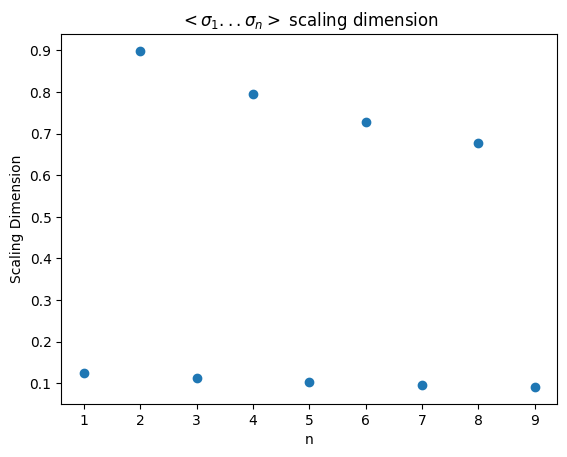

In [274]:
plt.scatter([1,2,3,4,5,6,7,8,9],-x/2)
plt.ylabel("Scaling Dimension")
plt.xlabel("n")
plt.title(r"$<\sigma_1...\sigma_n>$ scaling dimension")

In [299]:
X = np.arange(10,50)

y= [[kb.P_n_correlations(n,xi,U,k,even=True) -kb.P_n(n,U,k,even=True)**2 for xi in X] for n in [1,2,3,4,5] ]


/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/scaling_dim/../../src/kblock_ising_model.py:130: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,T,k)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


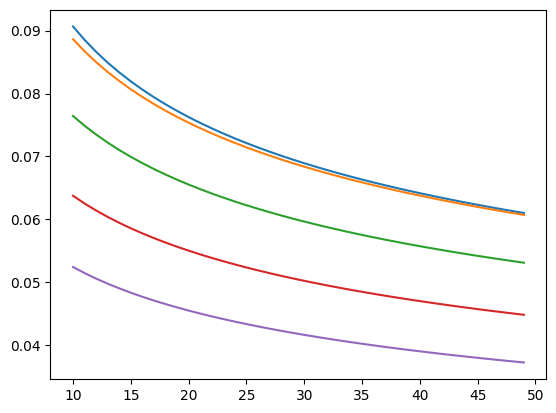

In [306]:
Y = np.array(y)

plt.plot(X,Y.T)


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_8714/324060891.py:4: RuntimeWarning: overflow encountered in exp
  return A*np.exp(-B*x)+C
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_8714/625168700.py:6: OptimizeWarning: Covariance of the parameters could not be estimated
  params_exp_law, cov_exp_law = curve_fit(exp_law,X,dat,maxfev=1000)


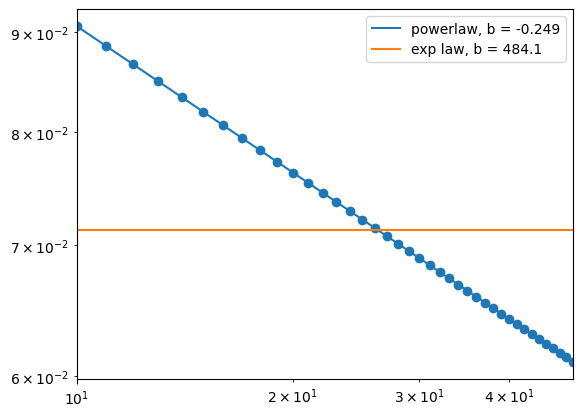

[1.60597919e-05 3.09479333e-05]
[inf inf inf]


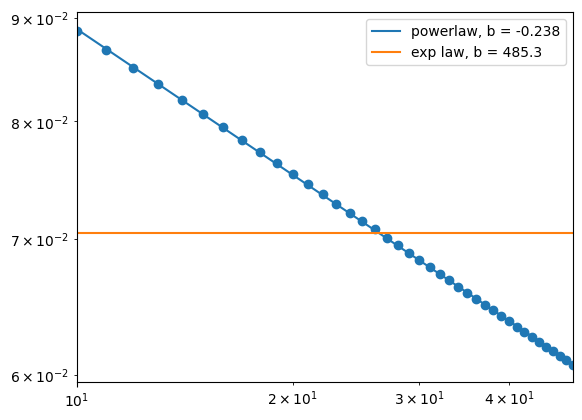

[0.00014992 0.00030159]
[inf inf inf]


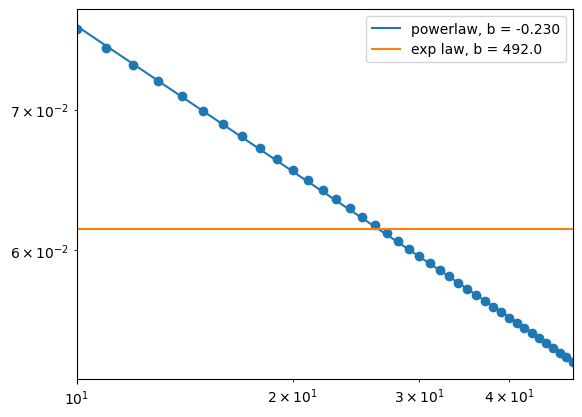

[0.00022241 0.00052795]
[inf inf inf]


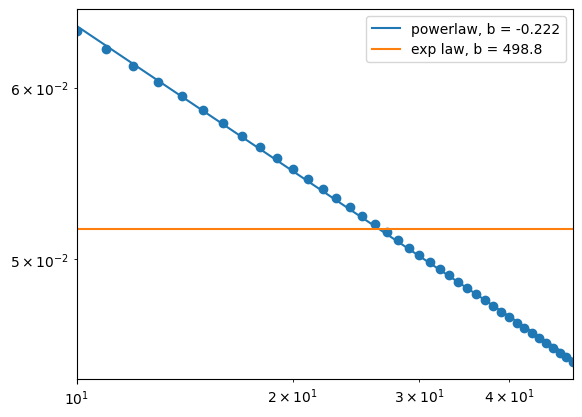

[0.00023822 0.0006882 ]
[inf inf inf]


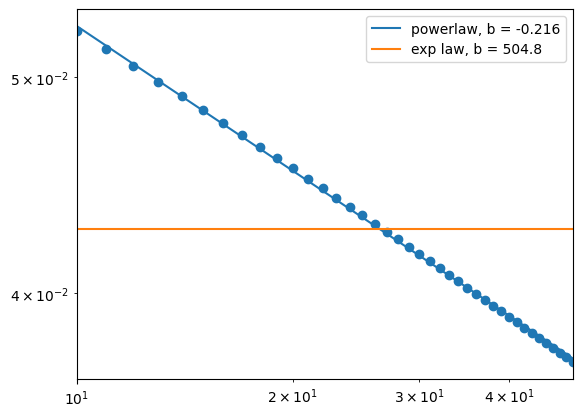

[0.00022588 0.00080394]
[inf inf inf]


(array([ 0.08678658, -0.21641889]),
 array([-4.70848535e+03,  5.04816865e+02,  4.27460367e-02]))

In [312]:
fit(Y[0,:],X)
fit(Y[1,:],X)
fit(Y[2,:],X)
fit(Y[3,:],X)
fit(Y[4,:],X)


In [321]:
args=(U,k)
X
d1 = np.array([kb.sigma_general([0,1,xi,xi+1],*args)-kb.sigma_general([0,1],*args)**2 for xi in X])
d2 = np.array([2*kb.sigma_general([0,xi],*args) for xi in X])
d3 = np.array([kb.sigma_general([0,xi+1],*args) for xi in X])
d4 = np.array([kb.sigma_general([0,xi-1],*args) for xi in X])

/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/scaling_dim/../../src/kblock_ising_model.py:130: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,T,k)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_8714/324060891.py:4: RuntimeWarning: overflow encountered in exp
  return A*np.exp(-B*x)+C
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_8714/625168700.py:6: OptimizeWarning: Covariance of the parameters could not be estimated
  params_exp_law, cov_exp_law = curve_fit(exp_law,X,dat,maxfev=1000)


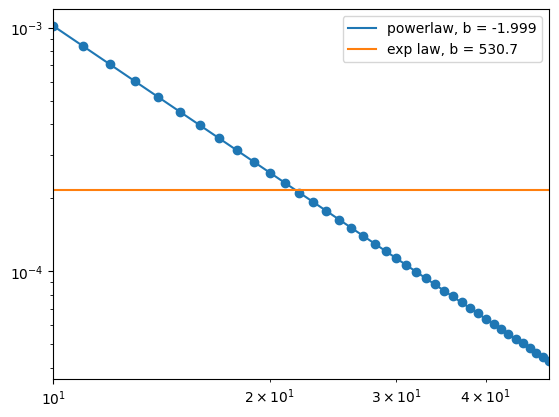

[7.99977984e-05 3.03761798e-04]
[inf inf inf]


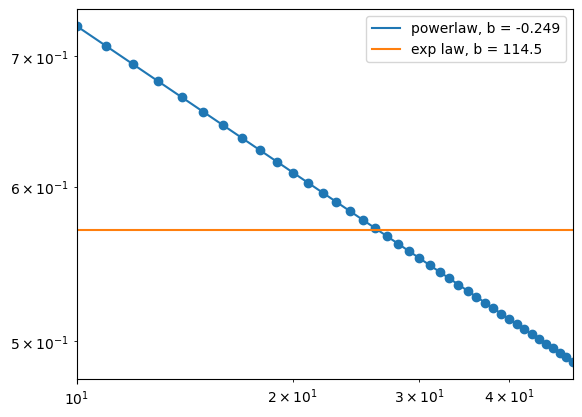

[1.28478336e-04 3.09479333e-05]
[inf inf inf]


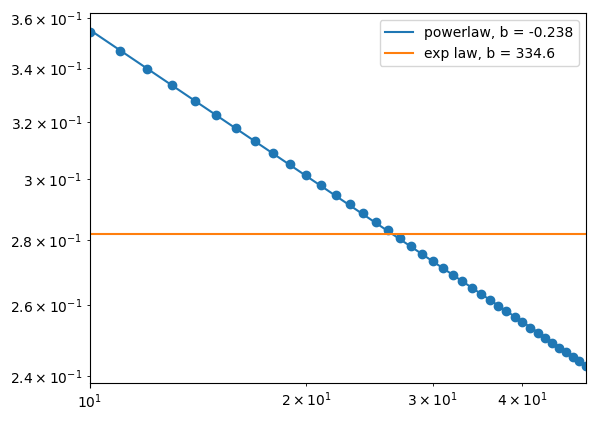

[0.00067335 0.00033943]
[inf inf inf]


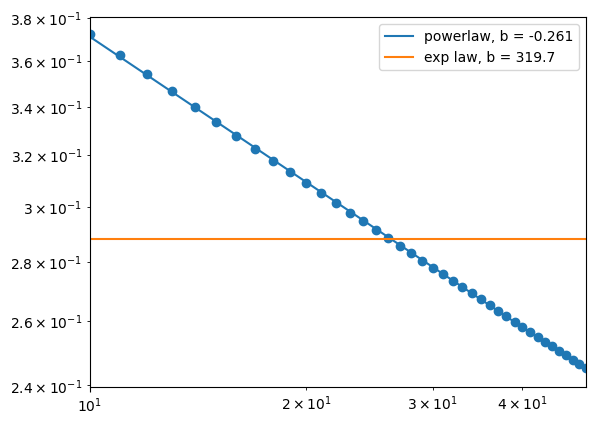

[0.00105059 0.00048145]
[inf inf inf]


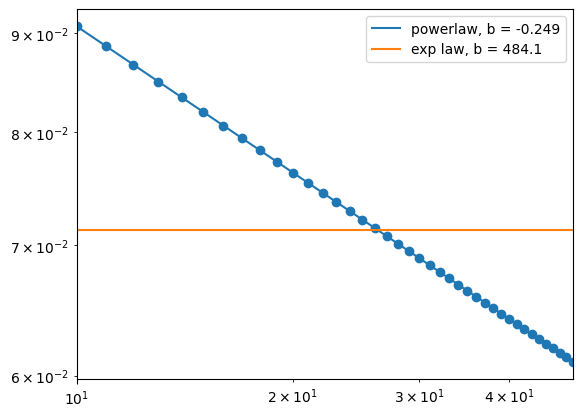

[2.88091029e-05 5.54378406e-05]
[inf inf inf]


(array([ 0.16121552, -0.24976933]),
 array([-4.50890663e+03,  4.84131301e+02,  7.12580466e-02]))

In [325]:
fit(d1,X)
fit(d2,X)
fit(d3,X)
fit(d4,X)

fit((0+d2+d3+d4)/16,X)

In [326]:
X

array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26,
       27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43,
       44, 45, 46, 47, 48, 49])

In [ ]:
args=(U,k)
X
d1 = np.array([kb.sigma_general([0,1,xi,xi+1],*args)-kb.sigma_general([0,1],*args)**2 for xi in X])
d2 = np.array([2*kb.sigma_general([0,xi],*args) for xi in X])
d3 = np.array([kb.sigma_general([0,xi+1],*args) for xi in X])
d4 = np.array([kb.sigma_general([0,xi-1],*args) for xi in X])



In [328]:
d5 = np.array([kb.P_n_correlations(2,xi,U,k) for xi in X])

/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/scaling_dim/../../src/kblock_ising_model.py:130: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,T,k)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/scaling_dim/../../src/kblock_ising_model.py:130: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,T,k)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_8714/324060891.py:4: RuntimeWarning: overflow encountered in exp
  return A*np.exp(-B*x)+C
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_8714/625168700.py:6: OptimizeWarning: Covariance of the parameters could not be estimated
  params_exp_law, cov_exp_law = curve_fit(exp_law,X,dat,maxfev=1000)


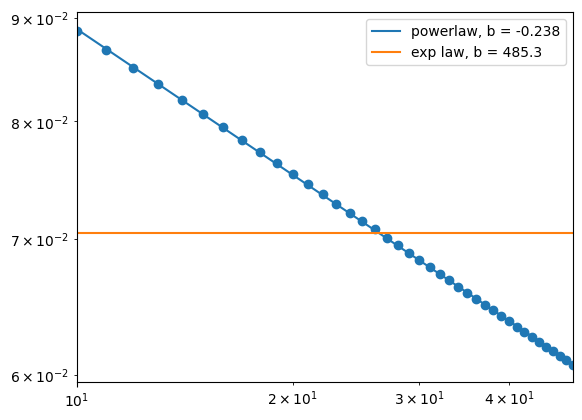

[0.00014992 0.00030159]
[inf inf inf]


(array([ 0.15398878, -0.23884344]),
 array([-4.52091670e+03,  4.85336591e+02,  7.05191451e-02]))

In [335]:
fit(d5-kb.P_n(2,U,k)**2,X)

/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/scaling_dim/../../src/kblock_ising_model.py:130: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,T,k)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_8714/625168700.py:6: OptimizeWarning: Covariance of the parameters could not be estimated
  params_exp_law, cov_exp_law = curve_fit(exp_law,X,dat,maxfev=1000)


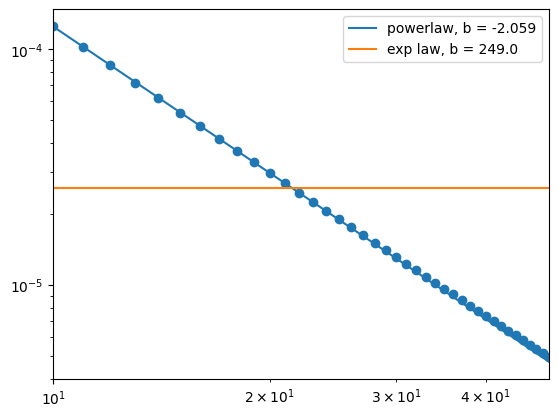

[0.00013791 0.00374217]
[inf inf inf]


(array([ 0.01427185, -2.05986699]),
 array([-2.39853255e+03,  2.49089987e+02,  2.56303291e-05]))

In [365]:
args=(U,k)
N = kb.sigma_general([0,1,2,3],*args)

d1 = np.array([kb.sigma_general([0,1,2,3,xi,xi+1,xi+2,xi+3],*args)-N**2 for xi in X])
d2 = 0#np.array([2*kb.sigma_general([0,xi],*args) for xi in X])
d3 = 0#np.array([kb.sigma_general([0,xi+1],*args) for xi in X])
d4 = 0#np.array([kb.sigma_general([0,xi-1],*args) for xi in X])

d6 = (d1+d2+d3+d4)/16
fit(d6,X)


/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/scaling_dim/../../src/kblock_ising_model.py:130: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,T,k)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_8714/324060891.py:4: RuntimeWarning: overflow encountered in exp
  return A*np.exp(-B*x)+C
/var/folders/tb/9nr_h

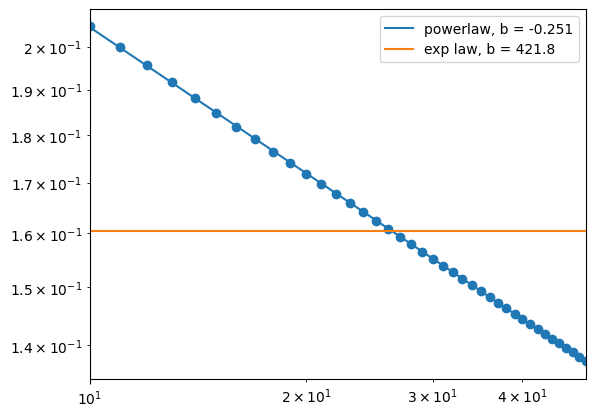

[0.00024422 0.00020724]
[inf inf inf]


(array([ 0.36570227, -0.25196906]),
 array([-3.90576265e+03,  4.21829095e+02,  1.60493705e-01]))

In [367]:
args=(U,k)
N = 0#kb.sigma_general([0,1,2,3],*args)

d1 = np.array([kb.sigma_general([0,1,2,xi,xi+1,xi+2],*args)-N**2 for xi in X])


fit(d1,X)

In [407]:
X = np.logspace(1,2,dtype=int)

N = 0
dat =np.array( [kb.D(xi,U,k) for xi in X])
dat2= np.array([kb.D(-xi,U,k) for xi in X])

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_8714/324060891.py:4: RuntimeWarning: overflow encountered in exp
  return A*np.exp(-B*x)+C
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_8714/324060891.py:4: RuntimeWarning: overflow encountered in multiply
  return A*np.exp(-B*x)+C
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_8714/625168700.py:6: OptimizeWarning: Covariance of the parameters could not be estimated
  params_exp_law, cov_exp_law = curve_fit(exp_law,X,dat,maxfev=1000)


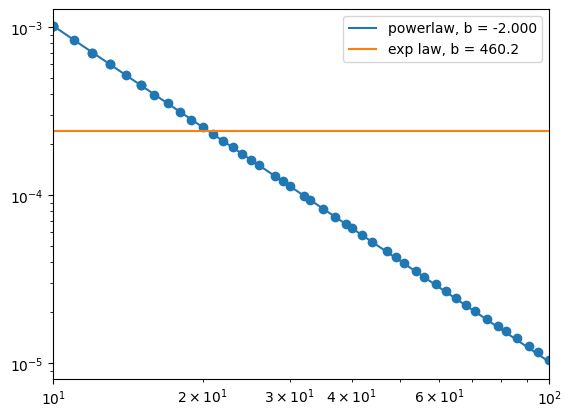

[9.03809095e-05 3.55876780e-04]
[inf inf inf]


(array([ 0.10165951, -2.00034697]),
 array([-4.36692738e+03,  4.60225327e+02,  2.40188009e-04]))

In [408]:
fit(-dat*dat2,X)


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_8714/324060891.py:4: RuntimeWarning: overflow encountered in exp
  return A*np.exp(-B*x)+C
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_8714/625168700.py:6: OptimizeWarning: Covariance of the parameters could not be estimated
  params_exp_law, cov_exp_law = curve_fit(exp_law,X,dat,maxfev=1000)


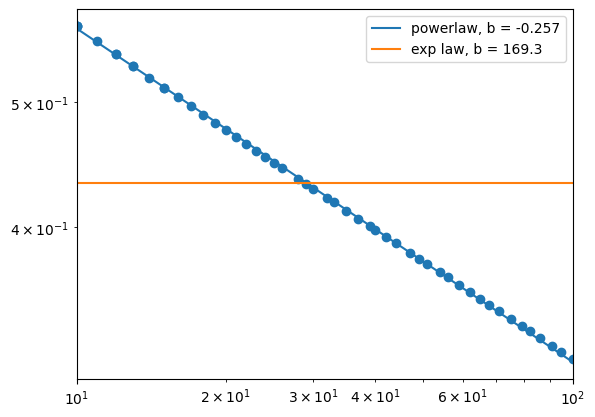

[0.00176144 0.00052365]
[inf inf inf]


(array([ 1.03090546, -0.25754121]),
 array([-1.59032718e+03,  1.69333353e+02,  4.32511115e-01]))

In [421]:
fit(X**(-1/4)+X**(-2.0),X)

In [457]:
X = np.logspace(1,2.3,100,dtype=int)
print(X)
N = kb.P_n(2,U,k)**2
dat =np.array( [kb.P_n_correlations(2,xi,U,k) -N for xi in X])


[ 10  10  10  10  11  11  11  12  12  13  13  13  14  14  15  15  16  16
  17  17  18  18  19  20  20  21  21  22  23  24  24  25  26  27  27  28
  29  30  31  32  33  34  35  36  37  38  40  41  42  43  45  46  48  49
  51  52  54  56  57  59  61  63  65  67  69  71  73  75  78  80  83  85
  88  90  93  96  99 102 105 108 112 115 119 122 126 130 134 138 143 147
 151 156 161 166 171 176 182 187 193 199]


8.0

[2.5777124 3.647585 ]
[4.17141224e-12 1.06919413e-03]


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_8714/324060891.py:4: RuntimeWarning: overflow encountered in exp
  return A*np.exp(-B*x)+C
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_8714/625168700.py:6: OptimizeWarning: Covariance of the parameters could not be estimated
  params_exp_law, cov_exp_law = curve_fit(exp_law,X,dat,maxfev=1000)


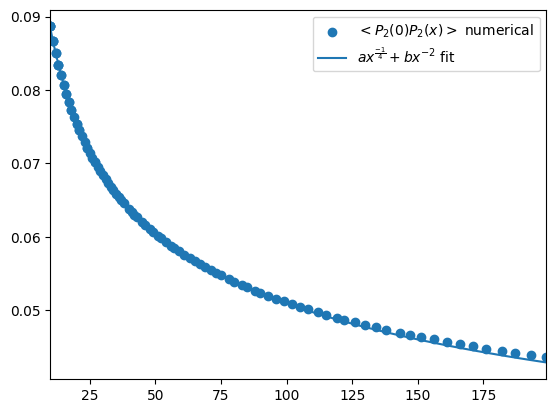

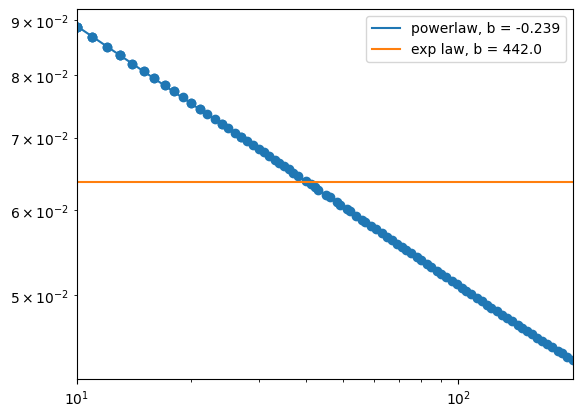

[8.91949322e-05 1.64246400e-04]
[inf inf inf]


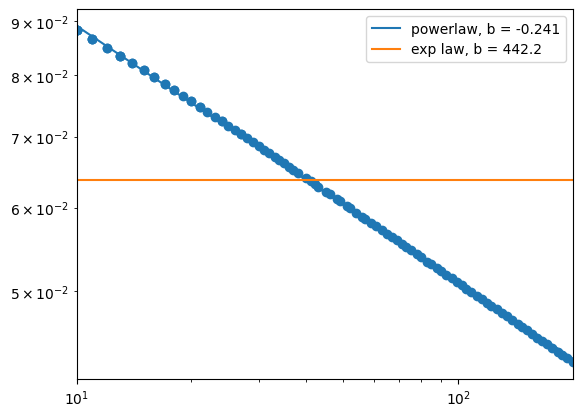

[0.00026794 0.00049   ]
[inf inf inf]


(array([ 0.15547006, -0.24187459]),
 array([-4.18877626e+03,  4.42245469e+02,  6.37154552e-02]))

In [491]:
def ansatz(X,a,b):
    return a*X**(-1/4)/16 - b*X**(-2.0)/16
params_ansatz , cov_ansatz = curve_fit(ansatz, X, dat)
plt.scatter(X,dat,label=r"$<P_2(0) P_2(x)>$ numerical")

plt.plot(X,ansatz(X,*params_ansatz),label=r"$ax^\frac{-1}{4}+bx^{{-2}}$ fit")
plt.legend()
#plt.yscale("log")
#plt.xscale("log")
plt.xlim(10,X[-1])


print(params_ansatz)
print(np.diag(cov_ansatz)**2)
plt.figure()
fit(dat,X)
fit(ansatz(X,*params_ansatz),X)


In [471]:
T = [kb.sigma_general([0,1,xi,xi+1],U,k)-kb.sigma_general([0,1],U,k)**2 for xi in X]

/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/scaling_dim/../../src/kblock_ising_model.py:130: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,T,k)


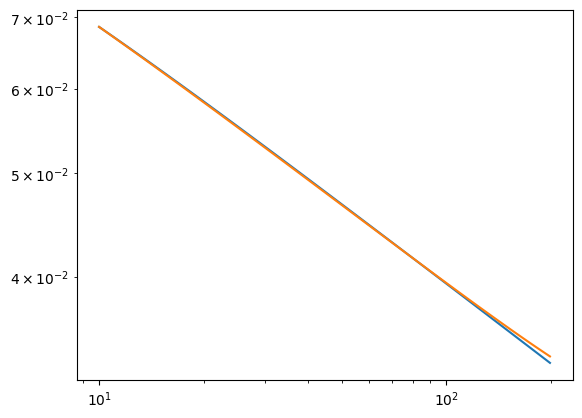

In [523]:
G= (2*X**(-1/4)-(X-1)**(-1/4)+(X+1)**(-1/4))/16   #-X**(-2.0)/16
plt.loglog(X,G)
plt.loglog(X,dat/dat[0]*G[0])

In [524]:
X = np.logspace(1,2.3,100,dtype=int)
print(X)
N = kb.P_n(3,U,k)**2
dat =np.array( [kb.P_n_correlations(3,xi,U,k) -N for xi in X])

[ 10  10  10  10  11  11  11  12  12  13  13  13  14  14  15  15  16  16
  17  17  18  18  19  20  20  21  21  22  23  24  24  25  26  27  27  28
  29  30  31  32  33  34  35  36  37  38  40  41  42  43  45  46  48  49
  51  52  54  56  57  59  61  63  65  67  69  71  73  75  78  80  83  85
  88  90  93  96  99 102 105 108 112 115 119 122 126 130 134 138 143 147
 151 156 161 166 171 176 182 187 193 199]


/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/scaling_dim/../../src/kblock_ising_model.py:130: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,T,k)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_8714/324060891.py:4: RuntimeWarning: overflow encountered in exp
  return A*np.exp(-B*x)+C
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_8714/625168700.py:6: OptimizeWarning: Covariance of the parameters could not be estimated
  params_exp_law, cov_exp_law = curve_fit(exp_law,X,dat,maxfev=1000)


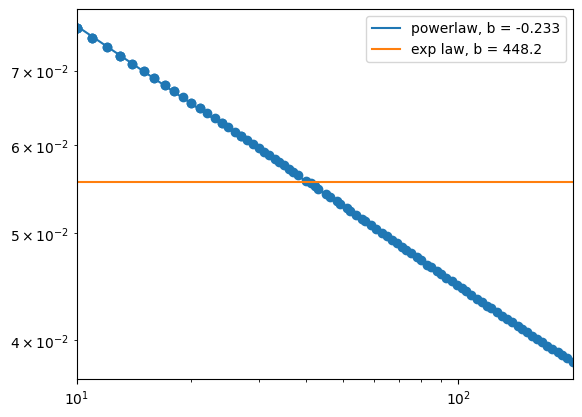

[0.00014233 0.00030677]
[inf inf inf]


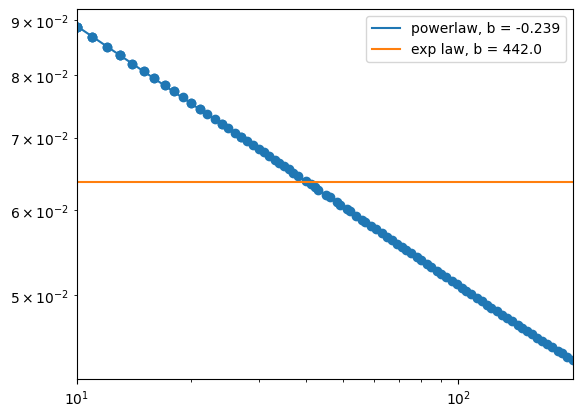

[8.91949322e-05 1.64246400e-04]
[inf inf inf]


(array([ 0.15425518, -0.23957395]),
 array([-4.18683221e+03,  4.42052085e+02,  6.37469326e-02]))

In [533]:
#plt.loglog(X,dat)
Y= np.array( [kb.P_n_correlations(2,xi,U,k) - kb.P_n(2,U,k)**2 for xi in X])
fit(dat,X)
fit(Y,X)


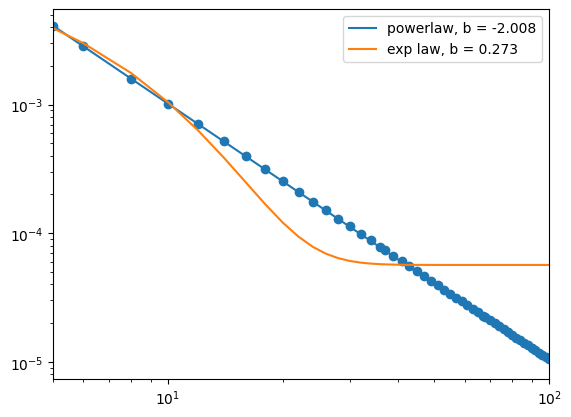

[0.00011632 0.00062596]
[8.35630128e-04 9.18729123e-03 1.11748981e-05]


(array([ 0.10362175, -2.00804278]),
 array([[ 1.35311004e-08, -7.19332223e-08],
        [-7.19332223e-08,  3.91824797e-07]]))

In [565]:
X = np.linspace(5,100,dtype=int)

def D(n,U,k):
    j=-n+1 
    return kb.BA([U,k,j])
z= [-D(xi,U,k)*D(-xi,U,k) for xi in X]
fit(z,X)
curve_fit(power_law, X, z)


/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


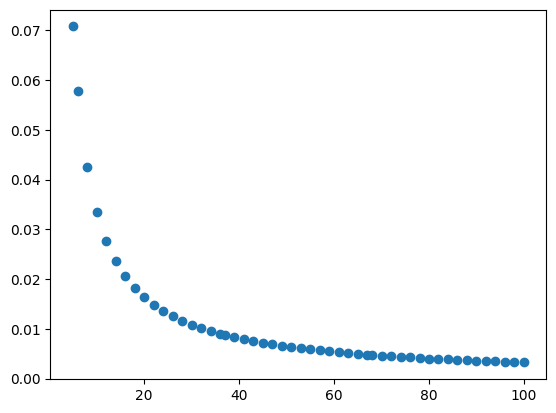

In [574]:
plt.scatter(X,[kb.BA([U,k,li]) for li in X])

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:644: ComplexWarning: Casting complex values to real discards the imaginary part
  a = asarray(a, dtype=dtype, order=order)


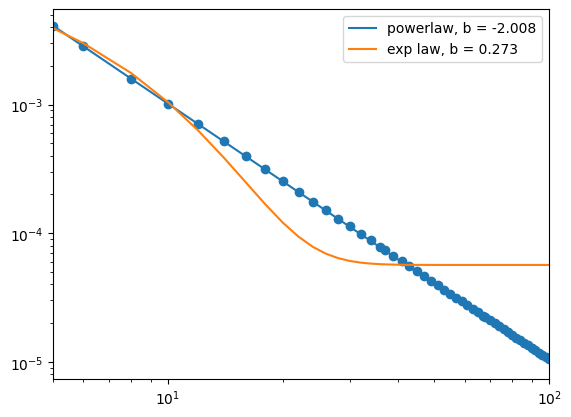

[0.00011632 0.00062596]
[8.35630128e-04 9.18729123e-03 1.11748981e-05]


(array([ 0.10362175, -2.00804278]),
 array([[ 1.35311004e-08, -7.19332223e-08],
        [-7.19332223e-08,  3.91824797e-07]]))

In [575]:
X = np.linspace(5,100,dtype=int)

def D(n,U,k):
    j=-n+1 
    return kb.BA([U,k,j])
z= [-D(xi,U,k)*D(-xi,U,k) for xi in X]
fit(z,X)
curve_fit(power_law, X, z)


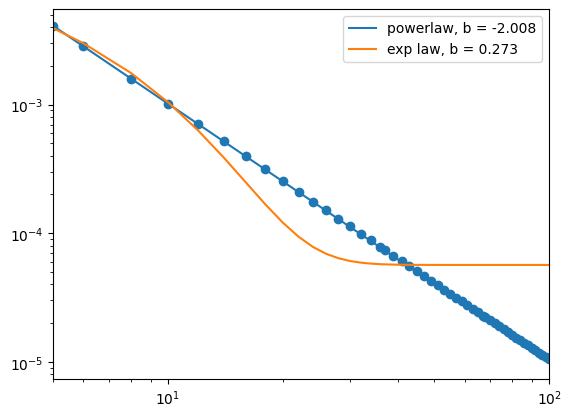

[0.00011632 0.00062596]
[8.35630120e-04 9.18729119e-03 1.11748980e-05]


(array([ 0.10362175, -2.00804278]),
 array([[ 1.35311005e-08, -7.19332229e-08],
        [-7.19332229e-08,  3.91824801e-07]]))

In [578]:
z= [-D(xi+1,U,k)*D(1-xi,U,k) for xi in X]
fit(z,X)
curve_fit(power_law, X, z)

In [8]:
N = kb.sigma_general([0,1],U,k)
test = np.array([kb.sigma_general([0,1,xi,xi+1],U,k) for xi in X])


/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/scaling_dim/../../src/kblock_ising_model.py:130: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,T,k)


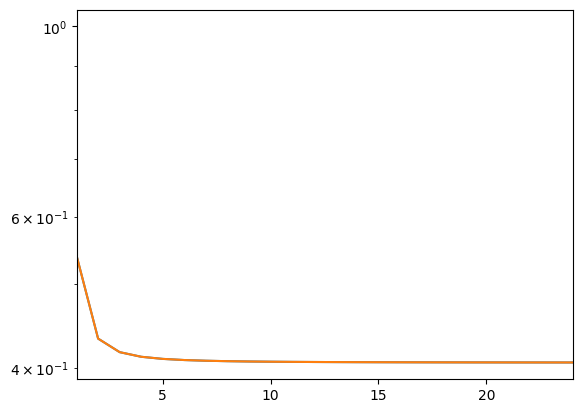

In [15]:
plot(X,test)
plot(X,4/np.pi/np.pi-4/(np.pi-2*np.pi*X)/(np.pi+2*np.pi*X))
plt.xlim(1,X[-1])
plt.yscale("log")